We fit the paramters of the model by performing a maximum likelihood estimate with just the upcrossing data. Assuming given the level u, total time of recording T, number of datapoints n, and the time stamps of the upcrossings and the downcrossings. The question is to estimate the parameters of the process with OU-noise: tau_f, tau_f, sigma.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import scipy
import scipy.linalg
import math
import gaussian_crossings.utils as utils
import gaussian_crossings.formula as formula
import gaussian_crossings.process as process

In [2]:
# Simulate the process
T = 20.0                       # Total simulation time.
omega0 = math.sqrt(10.0)                   # Fundamental frequency
zeta = 1.0                      # Damping ratio
temp = 10.0                     # Temperature (similar to sigma ** 2)

if zeta < 1.0:
    dt = 0.01 / (omega0 * max(zeta, math.sqrt(1 - zeta**2)))  
elif zeta == 1.0:
    dt = 0.01 / omega0
else:
    dt = 0.01 / (omega0 * max(zeta + math.sqrt(zeta**2 - 1), zeta - math.sqrt(zeta**2 - 1)))

u = 0.5                         # Threshold.
n = 100                         # Number of trials

In [3]:
# Simulate the process and record the crossing times.
upcrossing_times = []
downcrossing_times = []

for i in range(n):
    t, x = utils.simulate_gaussian_process_fft(
        process.r_damped_harmonic_oscillator_noise, T, dt,
        temp=temp, zeta=zeta, omega0=omega0
    )
    upcrossing_times.append(utils.upcrossing_times(x=x, t=t, threshold=u))
    downcrossing_times.append(utils.downcrossing_times(x=x, t=t, threshold=u))

# --------------------------------------------------------------------
# Compute observed upcrossings count per trial
observed_counts = torch.tensor([len(times) for times in upcrossing_times], dtype=torch.float32)
# print("Observed counts:", observed_counts.tolist())

In [4]:
# functions to find the mean and variance of the upcrossing counts.
model = formula.GaussianUpCrossings(r_func=process.r_damped_harmonic_oscillator_noise, u=u, temp=temp, zeta=zeta, omega0=omega0)
mean_num_upcrossings = model.upcrossing_mean(T)
variance_num_upcrossings = model.upcrossing_variance(T)
variance_num_upcrossings_CLT = model.upcrossing_variance_CLT(T)

# print the mean and variance of the upcrossing counts.
print(f"Analytical mean number of upcrossings: {mean_num_upcrossings}")
print(f"Analytical variance of the number of upcrossings: {variance_num_upcrossings}")
print(f"Analytical variance (CLT) of the number of upcrossings: {variance_num_upcrossings_CLT}")

# print the numerical mean and variance of the upcrossing counts.
print(f"Numerical mean number of upcrossings: {observed_counts.mean()}")
print(f"Numerical variance of the number of upcrossings: {observed_counts.var()}")
print(f"Numerical variance (biased) of the number of upcrossings: {torch.var(observed_counts, correction=0)}")


# the values to fit to
# true_mean = observed_counts.mean()
# true_var = torch.var(observed_counts, correction=0) # biased estimate as given by the log likelihood

true_mean = mean_num_upcrossings
true_var = variance_num_upcrossings

Analytical mean number of upcrossings: 8.883074758346588
Analytical variance of the number of upcrossings: 6.2816837771425345
Analytical variance (CLT) of the number of upcrossings: 6.208057094738453
Numerical mean number of upcrossings: 8.59000015258789
Numerical variance of the number of upcrossings: 6.688787937164307
Numerical variance (biased) of the number of upcrossings: 6.6219000816345215


In [5]:
# Set up parameters for optimization.
log_zeta = torch.tensor(np.log(3.0), dtype=torch.float64, requires_grad=True)
log_omega0 = torch.tensor(np.log(2.0), dtype=torch.float64, requires_grad=True)
log_temp = torch.tensor(np.log(10.0), dtype=torch.float64, requires_grad=False)

zeta = torch.exp(log_zeta).item()
omega0 = torch.exp(log_omega0).item()
temp = torch.exp(log_temp).item()

# Print the initial parameters
print("Initial parameters:")
print(f"zeta: {zeta}")
print(f"omega0: {omega0}")
print(f"temp: {temp}")


print("Analytical mean and variance with intial parameters:")
model_init = formula.GaussianUpCrossings(r_func=process.r_damped_harmonic_oscillator_noise, u=u, temp=temp, zeta=zeta, omega0=omega0)
mean_num_upcrossings_init = model_init.upcrossing_mean(T)
variance_num_upcrossings_init = model_init.upcrossing_variance(T)
print(f"Mean number of upcrossings : {mean_num_upcrossings_init}")
print(f"Variance of the number of upcrossings : {variance_num_upcrossings_init}")

# Choose an optimizer
optimizer = torch.optim.Adam([log_zeta, log_omega0, log_temp], lr=1e-2)

Initial parameters:
zeta: 3.0
omega0: 2.0
temp: 10.000000000000002
Analytical mean and variance with intial parameters:
Mean number of upcrossings : 6.055714596949899
Variance of the number of upcrossings : 9.612755584474513


Epoch    0: Loss = 21.0886, zeta = 3.000000, omega0 = 2.000000, temp = 10.000000
Epoch  100: Loss = 2.2892, zeta = 1.500356, omega0 = 2.615174, temp = 10.000000
Epoch  200: Loss = 0.0631, zeta = 1.085365, omega0 = 3.072439, temp = 10.000000
Epoch  300: Loss = 0.0005, zeta = 1.020832, omega0 = 3.154184, temp = 10.000000
Epoch  400: Loss = 0.0000, zeta = 1.014828, omega0 = 3.161921, temp = 10.000000
Epoch  500: Loss = 0.0000, zeta = 1.014567, omega0 = 3.162265, temp = 10.000000
Epoch  600: Loss = 0.0000, zeta = 1.014564, omega0 = 3.162275, temp = 10.000000
Epoch  700: Loss = 0.0000, zeta = 1.014565, omega0 = 3.162293, temp = 10.000000
Epoch  800: Loss = 0.0000, zeta = 1.014565, omega0 = 3.162257, temp = 10.000000
Epoch  900: Loss = 0.0000, zeta = 1.014567, omega0 = 3.162271, temp = 10.000000
Epoch 1000: Loss = 0.0000, zeta = 1.014563, omega0 = 3.162248, temp = 10.000000
Epoch 1100: Loss = 0.0000, zeta = 1.014563, omega0 = 3.162286, temp = 10.000000
Epoch 1200: Loss = 0.0000, zeta = 1.014

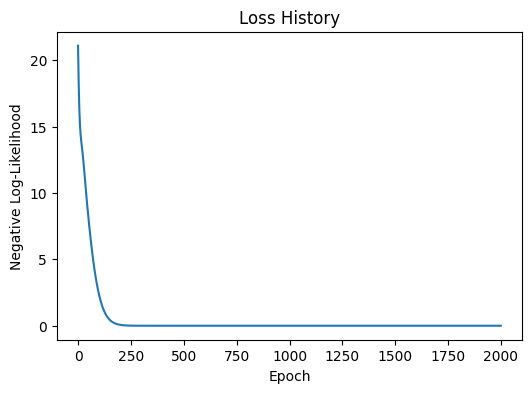

In [6]:
# For tracking the loss history
num_epochs = 2000
loss_history = []

# --------------------------------------------------------------------
# Optimization loop
for epoch in range(num_epochs):
    optimizer.zero_grad()
    
    # Convert log parameters to actual parameters ensuring positivity.
    zeta_est = torch.exp(log_zeta)
    omega0_est = torch.exp(log_omega0)
    temp_est = torch.exp(log_temp)
    
    # Create a model instance with the current estimates.
    model_est = formula.GaussianUpCrossings(
        r_func=process.r_damped_harmonic_oscillator_noise, u=u,  temp=temp_est, zeta=zeta_est, omega0=omega0_est
    )
    
    # Compute the predicted mean and variance for the number of upcrossings over time T.
    mean_est = model_est.upcrossing_mean(T)
    # var_est = model_est.upcrossing_variance(T)
    var_est = model_est.upcrossing_variance_CLT(T)

    # print(f"Mean number of upcrossings: {mean_est}")
    # print(f"Variance of the number of upcrossings: {var_est}")
    
    # Define the negative log likelihood assuming a Gaussian likelihood for the counts.
    # For each trial, NLL = 0.5*log(2*pi*var) + 0.5*(observed - mean)^2 / var.
    # nll = 0.5 * torch.log(2 * torch.pi * var_est) + 0.5 * ((observed_counts - mean_est)**2) / var_est
    # # nll = (observed_counts - mean_est)**2 ## minimize the mean
    # loss = nll.mean()  # Sum over all trials.

    
    # loss = (mean_est - true_mean) ** 2 ## minimize the mean
    # loss = (var_est - true_var) ** 2 ## minimize the variance
    loss = (mean_est - true_mean) ** 2 + (var_est - true_var) ** 2 ## minimize both mean and variance

    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d}: Loss = {loss.item():.4f}, "
              f"zeta = {zeta_est.item():.6f}, omega0 = {omega0_est.item():.6f}, temp = {temp_est.item():.6f}")

    
    # Backpropagate the loss.
    loss.backward()

    # print the gradient for each parameter
    # print(f"Gradient tau_e: {log_tau_e.grad}")
    # print(f"Gradient sigma : {log_sigma.grad}")

    optimizer.step()
    
    loss_history.append(loss.item())
    

print("Optimization complete!")

zeta = torch.exp(log_zeta).item()
omega0 = torch.exp(log_omega0).item()
temp = torch.exp(log_temp).item()


print("Estimated parameters:")
print(f"zeta: {zeta}")
print(f"omega0: {omega0}")
print(f"temp: {temp}")

# Optional: Plot loss history
plt.figure(figsize=(6, 4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Negative Log-Likelihood")
plt.title("Loss History")
plt.show()

In [7]:
# print the simulation mean and variance with true paramters and learned paramteres
print("Simulation mean and variance with true parameters:")
print(f"Mean number of upcrossings: {torch.mean(observed_counts)}")
print(f"Variance of the number of upcrossings: {torch.var(observed_counts, correction=0)}")
print(f"Variance (biased) of the number of upcrossings: {torch.var(observed_counts, correction=0)} \n")

# print the analytical mean and variance with true paramters and learned paramteres
print("Analytical mean and variance with true parameters:")
print(f"Mean number of upcrossings: {mean_num_upcrossings}")
print(f"Variance of the number of upcrossings: {variance_num_upcrossings} \n")


print("Analytical mean and variance with estimated parameters:")
model_est = formula.GaussianUpCrossings(r_func=process.r_damped_harmonic_oscillator_noise, u=u, temp=temp, zeta=zeta, omega0=omega0)
mean_num_upcrossings_est = model_est.upcrossing_mean(T)
variance_num_upcrossings_est = model_est.upcrossing_variance(T)
print(f"Mean number of upcrossings (estimated): {mean_num_upcrossings_est}")
print(f"Variance of the number of upcrossings (estimated): {variance_num_upcrossings_est}")

Simulation mean and variance with true parameters:
Mean number of upcrossings: 8.59000015258789
Variance of the number of upcrossings: 6.6219000816345215
Variance (biased) of the number of upcrossings: 6.6219000816345215 

Analytical mean and variance with true parameters:
Mean number of upcrossings: 8.883074758346588
Variance of the number of upcrossings: 6.2816837771425345 

Analytical mean and variance with estimated parameters:
Mean number of upcrossings (estimated): 8.883031566989775
Variance of the number of upcrossings (estimated): 6.353385002411738
